# Visualizing Point Density in Scatterplots

When working with scatterplots, sometimes many points overlap in the same region.  
This can make it hard to see where the data is most concentrated.

In this notebook, we will explore two ways to better visualize **density** of datapoint in regions of a scatterplot:

1. **Use transparency (`alpha`)** so overlapping points become darker  
2. **Use a 2D histogram** to summarize the number of points in each region

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Penguins Dataset

We’ll once again use the Seaborn `penguins` dataset and look at the relationship between:

- `flipper_length_mm`
- `bill_depth_mm`

In [2]:
penguins = sns.load_dataset("penguins")
penguins.info()
penguins.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Basic Scatterplot

A standard scatterplot shows the relationship between two continuous variables.

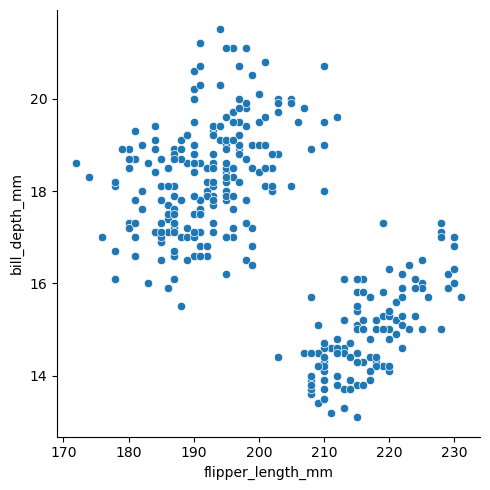

In [3]:
sns.relplot(data=penguins, x="flipper_length_mm", y="bill_depth_mm")
plt.show()

## Using Transparency to Visualize Density

If many points overlap, you can reduce the opacity using the `alpha` argument. Note that the `s` argument controls the size of the points and setting `edgecolor='none'` removes borders of points. You can see other possible arguments to control the style of points at the documentation [here](https://seaborn.pydata.org/tutorial/properties.html).

Overlapping semi-transparent points makes dense areas appear darker because points stack on top of each other.

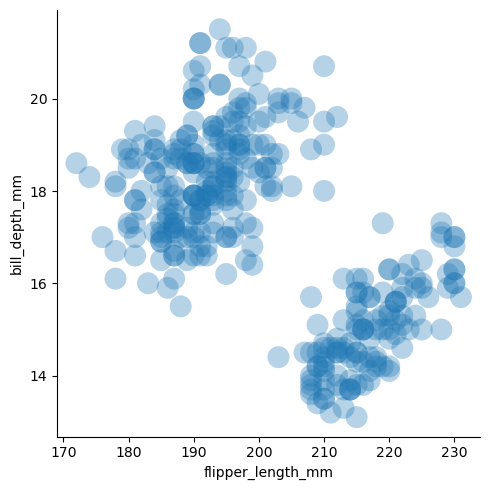

In [4]:
sns.relplot(data=penguins, x="flipper_length_mm", y="bill_depth_mm", s=250, alpha=0.33, edgecolor='none')
plt.show()

With transparency:
- Areas with **few points** stay light
- Areas with **many overlapping points** look darker

This gives a visual sense of **where the data is concentrated**.

## 2D Histograms as Another Way to Show Density

A 2D histogram divides the x-y plane into rectangular bins and counts how many points fall into each bin.

This is useful when:
- there are many overlapping points
- you want a more direct summary of density across regions

Here we'll use Seaborn's figure-level `displot` function, just like we did with regular histograms.

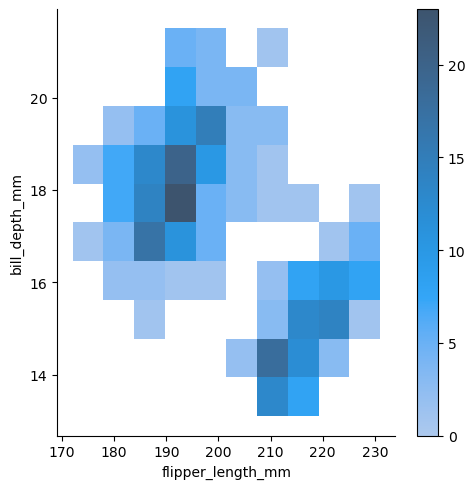

In [5]:
sns.displot(data=penguins, x="flipper_length_mm", y="bill_depth_mm", kind="hist", cbar=True)
plt.show()

## Interpreting the Color Bar

In the 2D histogram:
- Each tile represents a region of the x-y space
- The **color intensity** shows how many observations fall in that region
- The color bar (`cbar=True`) provides the count scale

Darker or more intense color means **more points** in that area.

## Comparing the Two

### Transparency in Scatterplots
- Keeps the exact points visible
- Good when you still want to see individual observations
- Helps with moderate overlap

### 2D Histogram
- Summarizes data into bins
- Better for heavier overlap
- Makes concentration patterns easier to read

## Practice Exercises

1. Create a scatterplot of `bill_length_mm` vs `bill_depth_mm` using transparency (`alpha=0.3`).

2. Increase the point size (`s`) in the transparent scatterplot. How does that affect your ability to see dense regions?

3. Create a 2D histogram for `bill_length_mm` vs `bill_depth_mm` with `cbar=True`.

4. Compare the transparent scatterplot and the 2D histogram. Which one do you think gives a clearer picture of density?